# GPU + NPU Combined Roofline Model

Sweeps the repeat count `R` to vary arithmetic intensity, running GPU and NPU **in parallel** for each point via the `mul_bench_parallel_test` C++ binary.  
Arithmetic intensity = R/2 FLOPs/Byte for both devices.

In [1]:
import json
import subprocess
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

In [2]:
# ── Configuration ─────────────────────────────────────────────────────────────
NOTEBOOK_DIR = Path.cwd()
REPO_ROOT    = NOTEBOOK_DIR          # notebook lives at repo root
BINARY       = REPO_ROOT / "iron" / "operators" / "mul_bench" / "mul_bench_parallel_test"
BENCH_DIR    = BINARY.parent

SIZE_GPU     = 1 << 20   # 16-bit elements for GPU  (16 M fp16)
SIZE_NPU     = 1 << 20   # 16-bit elements for NPU  ( 1 M bf16, must be a multiple of 65536)

# Work multipliers — kernel launches per timed sample.
# R controls arithmetic intensity (same for both devices).
# ITERS_GPU / ITERS_NPU scale wall-clock work per sample without changing AI.
ITERS_GPU    = 1
ITERS_NPU    = 1

NPU_COLUMNS  = 8
NPU_CHANNELS = 2
NPU_TILE_SZ  = 8192

RUN_GPU      = True    # set False for NPU-only
RUN_NPU      = True      # set False for GPU-only (skips NPU artifact check)

# R values to sweep (controls arithmetic intensity = R/2 FLOPs/Byte)
R_VALUES = list(range(1, 3001, 50))

# ── Validation ────────────────────────────────────────────────────────────────
if not RUN_GPU and not RUN_NPU:
    raise ValueError("RUN_GPU and RUN_NPU are both False — nothing to run.")

NPU_ALIGNMENT = NPU_COLUMNS * NPU_TILE_SZ   # 65536 elements
if RUN_NPU and SIZE_NPU % NPU_ALIGNMENT != 0:
    multiples = [NPU_ALIGNMENT * k for k in range(1, 6)]
    raise ValueError(
        f"SIZE_NPU={SIZE_NPU:,} is not a multiple of "
        f"NPU_COLUMNS \u00d7 NPU_TILE_SZ = {NPU_ALIGNMENT:,}.\n"
        f"  Valid sizes: {', '.join(f'{m:,}' for m in multiples)}, \u2026"
    )

print(f"Binary:    {BINARY}  (exists: {BINARY.exists()})")
print(f"GPU size:  {SIZE_GPU:,} fp16 elements  (iters per sample: {ITERS_GPU})  ({'active' if RUN_GPU else 'DISABLED'})")
print(f"NPU size:  {SIZE_NPU:,} bf16 elements  (iters per sample: {ITERS_NPU})  ({'active' if RUN_NPU else 'DISABLED'})")
print(f"R sweep:   {R_VALUES[0]} \u2192 {R_VALUES[-1]} (step {R_VALUES[1]-R_VALUES[0]}, {len(R_VALUES)} points)")


Binary:    /home/steven/gpu_bench/IRON/iron/operators/mul_bench/mul_bench_parallel_test  (exists: True)
GPU size:  1,048,576 fp16 elements  (iters per sample: 1)  (active)
NPU size:  1,048,576 bf16 elements  (iters per sample: 1)  (active)
R sweep:   1 → 2951 (step 50, 60 points)


In [3]:
def artifact_stem(size_npu, r, num_columns=NPU_COLUMNS, num_channels=NPU_CHANNELS, tile_size=NPU_TILE_SZ):
    return f"MulBench_sz{size_npu}_c{num_columns}_ch{num_channels}_t{tile_size}_R{r}_npu2"
16777216

def ensure_npu_artifacts(r, size_npu=None):
    """Compile NPU xclbin/bin for this (size, r) if not already present."""
    if size_npu is None:
        size_npu = SIZE_NPU
    stem  = artifact_stem(size_npu, r)
    build = REPO_ROOT / "build"
    if (build / f"{stem}.xclbin").exists() and (build / f"{stem}.bin").exists():
        return
    print(f"  Compiling NPU artifact for R={r}...", end=" ", flush=True)
    result = subprocess.run(
        [
            sys.executable,
            "iron/operators/mul_bench/run_mul_bench_npu.py",
            "--size",         str(size_npu),
            "--r",            str(r),
            "--num-columns",  str(NPU_COLUMNS),
            "--num-channels", str(NPU_CHANNELS),
            "--tile-size",    str(NPU_TILE_SZ),
        ],
        cwd=str(REPO_ROOT),
        capture_output=True,
        text=True,
    )
    if result.returncode != 0:
        raise RuntimeError(
            f"NPU compilation failed for R={r}, size={size_npu}:\n"
            + (result.stderr[-500:] if result.stderr else "(no stderr)")
        )
    print("done")


def run_bench(r, size_gpu=None, size_npu=None, iters_gpu=None, iters_npu=None, run_gpu=None, run_npu=None, repeats=1):
    if size_gpu  is None: size_gpu  = SIZE_GPU
    if size_npu  is None: size_npu  = SIZE_NPU
    if iters_gpu is None: iters_gpu = ITERS_GPU
    if iters_npu is None: iters_npu = ITERS_NPU
    if run_gpu   is None: run_gpu   = RUN_GPU
    if run_npu   is None: run_npu   = RUN_NPU

    cmd = [
        str(BINARY),
        "--r",         str(r),
        "--size-gpu",  str(size_gpu),
        "--size-npu",  str(size_npu),
        "--iters-gpu", str(iters_gpu),
        "--iters-npu", str(iters_npu),
        "--repeats",   str(repeats),
        "--json",
    ]
    if not run_gpu:
        cmd.append("--no-gpu")
    if not run_npu:
        cmd.append("--no-npu")
    result = subprocess.run(cmd, cwd=str(BENCH_DIR), capture_output=True, text=True)
    if result.returncode != 0:
        raise RuntimeError(
            f"Binary failed (exit {result.returncode}):\n"
            + (result.stderr[-500:] if result.stderr else "(no stderr)")
        )
    last_line = result.stdout.strip().splitlines()[-1]
    return json.loads(last_line)


In [103]:


total_batches = 100
repeats      = 10

R_VALUES = list(range(1, 1601, 3))


In [104]:
R_VALUES = list(range(1, 3000, 1))

In [41]:
gpu_points2      = []
# ── GPU sweep ─────────────────────────────────────────────────────────────────
for idx, r in enumerate(R_VALUES):
    print(f"[{idx+1}/{len(R_VALUES)}] R={r:5d}  AI={r/2:.2f} FLOPs/Byte", end="  ", flush=True)
    try:
        datag = run_bench(r, iters_gpu=total_batches, run_gpu=True, run_npu=False, repeats=repeats)
        g = datag.get("gpu")
        if g:
            gpu_points2.append((g["arith_intensity"], g["tflops"]))
            print(f"GPU {g['tflops']:.4f} TFLOPS", end="  ", flush=True)
            print(f"GPU BW {g['bandwidth_gbps']:.2f} GB/s")
        else:
            print("no GPU result")
    except Exception as exc:
        print(f"FAILED: {exc}")

print(f"\nCollected {len(gpu_points2)} GPU points.")

[1/2999] R=    1  AI=0.50 FLOPs/Byte  GPU 0.0327 TFLOPS  GPU BW 65.36 GB/s
[2/2999] R=    2  AI=1.00 FLOPs/Byte  GPU 0.0687 TFLOPS  GPU BW 68.70 GB/s
[3/2999] R=    3  AI=1.50 FLOPs/Byte  GPU 0.1007 TFLOPS  GPU BW 67.15 GB/s
[4/2999] R=    4  AI=2.00 FLOPs/Byte  GPU 0.1315 TFLOPS  GPU BW 65.73 GB/s
[5/2999] R=    5  AI=2.50 FLOPs/Byte  GPU 0.1629 TFLOPS  GPU BW 65.17 GB/s
[6/2999] R=    6  AI=3.00 FLOPs/Byte  GPU 0.2021 TFLOPS  GPU BW 67.37 GB/s
[7/2999] R=    7  AI=3.50 FLOPs/Byte  GPU 0.2380 TFLOPS  GPU BW 68.00 GB/s
[8/2999] R=    8  AI=4.00 FLOPs/Byte  GPU 0.2694 TFLOPS  GPU BW 67.35 GB/s
[9/2999] R=    9  AI=4.50 FLOPs/Byte  GPU 0.3059 TFLOPS  GPU BW 67.97 GB/s
[10/2999] R=   10  AI=5.00 FLOPs/Byte  GPU 0.3405 TFLOPS  GPU BW 68.10 GB/s
[11/2999] R=   11  AI=5.50 FLOPs/Byte  GPU 0.3955 TFLOPS  GPU BW 71.91 GB/s
[12/2999] R=   12  AI=6.00 FLOPs/Byte  GPU 0.4087 TFLOPS  GPU BW 68.12 GB/s
[13/2999] R=   13  AI=6.50 FLOPs/Byte  GPU 0.4840 TFLOPS  GPU BW 74.46 GB/s
[14/2999] R=   14  AI

In [42]:
npu_points      = []
# ── NPU sweep ─────────────────────────────────────────────────────────────────
for idx, r in enumerate(R_VALUES):
    print(f"[{idx+1}/{len(R_VALUES)}] R={r:5d}  AI={r/2:.2f} FLOPs/Byte", end="  ", flush=True)
    try:
        if RUN_NPU:
            ensure_npu_artifacts(r)
        datan = run_bench(r, iters_npu=total_batches, run_gpu=False, run_npu=True, repeats=repeats)
        n = datan.get("npu")
        if n:
            npu_points.append((n["arith_intensity"], n["tflops"]))

            print(f"NPU {n['tflops']:.4f} TFLOPS", end="  ", flush=True)
            print(f"NPU BW {n['bandwidth_gbps']:.2f} GB/s")
        else:
            print("no NPU result")
    except Exception as exc:
        print(f"FAILED: {exc}")

print(f"\nCollected {len(npu_points)} NPU points.")

[1/2999] R=    1  AI=0.50 FLOPs/Byte  NPU 0.0147 TFLOPS  NPU BW 29.32 GB/s
[2/2999] R=    2  AI=1.00 FLOPs/Byte  NPU 0.0296 TFLOPS  NPU BW 29.60 GB/s
[3/2999] R=    3  AI=1.50 FLOPs/Byte  NPU 0.0439 TFLOPS  NPU BW 29.26 GB/s
[4/2999] R=    4  AI=2.00 FLOPs/Byte  NPU 0.0593 TFLOPS  NPU BW 29.65 GB/s
[5/2999] R=    5  AI=2.50 FLOPs/Byte  NPU 0.0756 TFLOPS  NPU BW 30.23 GB/s
[6/2999] R=    6  AI=3.00 FLOPs/Byte  NPU 0.0897 TFLOPS  NPU BW 29.90 GB/s
[7/2999] R=    7  AI=3.50 FLOPs/Byte  NPU 0.1042 TFLOPS  NPU BW 29.79 GB/s
[8/2999] R=    8  AI=4.00 FLOPs/Byte  NPU 0.1201 TFLOPS  NPU BW 30.02 GB/s
[9/2999] R=    9  AI=4.50 FLOPs/Byte  NPU 0.1353 TFLOPS  NPU BW 30.06 GB/s
[10/2999] R=   10  AI=5.00 FLOPs/Byte  NPU 0.1499 TFLOPS  NPU BW 29.99 GB/s
[11/2999] R=   11  AI=5.50 FLOPs/Byte  NPU 0.1653 TFLOPS  NPU BW 30.06 GB/s
[12/2999] R=   12  AI=6.00 FLOPs/Byte  NPU 0.1804 TFLOPS  NPU BW 30.06 GB/s
[13/2999] R=   13  AI=6.50 FLOPs/Byte  NPU 0.1950 TFLOPS  NPU BW 30.00 GB/s
[14/2999] R=   14  AI

In [184]:
# ── Combined sweep ────────────────────────────────────────────────────────────
npu_mem      = 30
gpu_mem      = 74.5
total_mem    = 74.5
npu_perf     = 6500
gpu_perf     = 7400
_total_mem = total_mem  # local copy — mutated per iteration like the original
combined_points2 = []
model_points     = []
R_VALUES = list(range(1, 3000, 1))
for idx, r in enumerate(R_VALUES):
    print(f"[{idx+1}/{len(R_VALUES)}] R={r:5d}  AI={r/2:.2f} FLOPs/Byte", end="  ", flush=True)
    try:
        ai       = r / 2
        gpu_need = min(gpu_perf / ai, gpu_mem)
        npu_need = min(npu_perf / ai, npu_mem)
        if gpu_need + npu_need < _total_mem:
            _total_mem = gpu_need + npu_need
        gpu_batches = int(total_batches * (gpu_need / _total_mem))
        npu_batches = total_batches - gpu_batches
        if npu_batches == 0:
            npu_batches = 1
            gpu_batches = total_batches - npu_batches
        model_points.append((ai, min(min(gpu_perf, gpu_mem * ai) + min(npu_perf, npu_mem * ai), _total_mem * ai) / 1000))
        if npu_batches == 0:
            data         = run_bench(r, iters_gpu=total_batches, run_npu=False, repeats=repeats)
            total_tflops = data.get("gpu", {}).get("tflops")
        else:
            data         = run_bench(r, iters_gpu=gpu_batches, iters_npu=npu_batches, repeats=repeats)
            total_tflops = data.get("combined_tflops")
        if total_tflops is not None:
            combined_points2.append((ai, total_tflops))
        print(f"Combined {total_tflops:.4f} TFLOPS" if total_tflops is not None else "no combined result", end ="  ", flush=True)
        print(f"Combined Bandwidth: {total_tflops*1000/ai:.2f} GB/s" if total_tflops is not None else "no combined result")
    except Exception as exc:
        print(f"FAILED: {exc}")

print(f"\nCollected {len(combined_points2)} combined points.")

[1/2999] R=    1  AI=0.50 FLOPs/Byte  Combined 0.0312 TFLOPS  Combined Bandwidth: 62.45 GB/s
[2/2999] R=    2  AI=1.00 FLOPs/Byte  Combined 0.0660 TFLOPS  Combined Bandwidth: 66.04 GB/s
[3/2999] R=    3  AI=1.50 FLOPs/Byte  Combined 0.1002 TFLOPS  Combined Bandwidth: 66.81 GB/s
[4/2999] R=    4  AI=2.00 FLOPs/Byte  Combined 0.1302 TFLOPS  Combined Bandwidth: 65.12 GB/s
[5/2999] R=    5  AI=2.50 FLOPs/Byte  Combined 0.1636 TFLOPS  Combined Bandwidth: 65.44 GB/s
[6/2999] R=    6  AI=3.00 FLOPs/Byte  Combined 0.1867 TFLOPS  Combined Bandwidth: 62.23 GB/s
[7/2999] R=    7  AI=3.50 FLOPs/Byte  Combined 0.2415 TFLOPS  Combined Bandwidth: 68.99 GB/s
[8/2999] R=    8  AI=4.00 FLOPs/Byte  Combined 0.2820 TFLOPS  Combined Bandwidth: 70.50 GB/s
[9/2999] R=    9  AI=4.50 FLOPs/Byte  Combined 0.3197 TFLOPS  Combined Bandwidth: 71.04 GB/s
[10/2999] R=   10  AI=5.00 FLOPs/Byte  Combined 0.3103 TFLOPS  Combined Bandwidth: 62.05 GB/s
[11/2999] R=   11  AI=5.50 FLOPs/Byte  Combined 0.3828 TFLOPS  Combin

Saved: /home/steven/gpu_bench/IRON/gpu_npu_combined_roofline.png


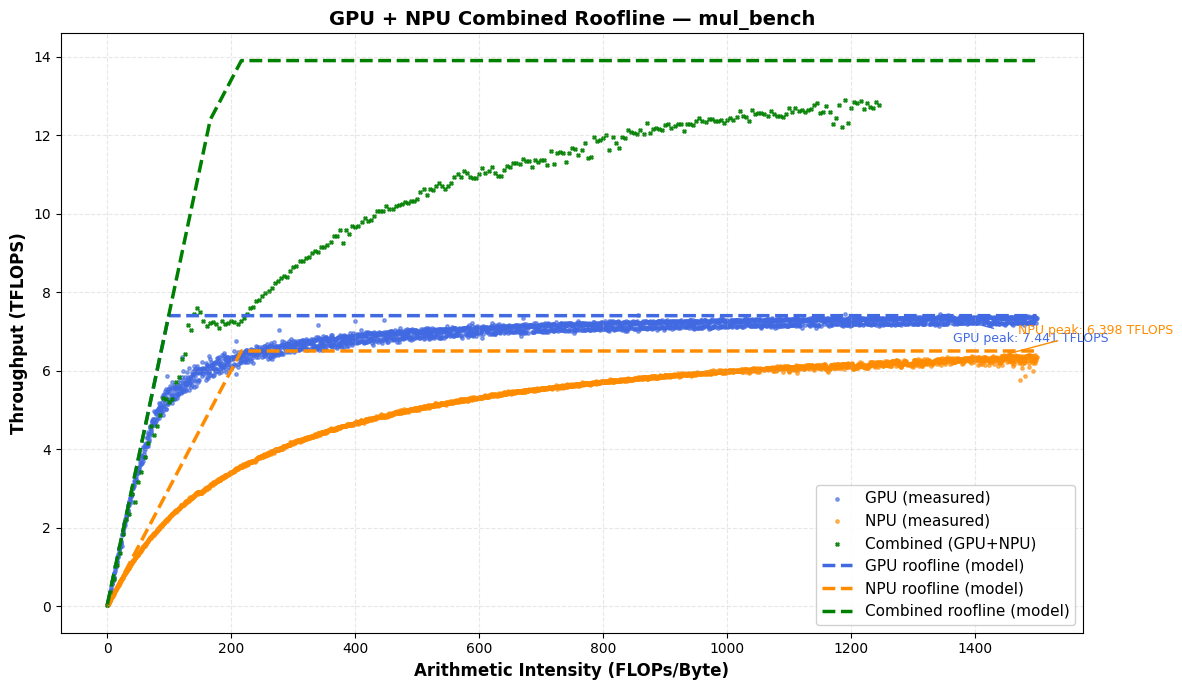

In [183]:
# ── Plot ───────────────────────────────────────────────────────────────────────
gpu_ai     = np.array([p[0] for p in gpu_points2])
gpu_tflops = np.array([p[1] for p in gpu_points2])
npu_ai     = np.array([p[0] for p in npu_points])
npu_tflops = np.array([p[1] for p in npu_points])
comb_ai   = np.array([p[0] for p in combined_points2 if p[1] is not None])
comb_tflops = np.array([p[1] for p in combined_points2 if p[1] is not None])

def upper_envelope(ai, tflops):
    order = np.argsort(ai)
    return ai[order], np.maximum.accumulate(tflops[order])

gpu_env_ai, gpu_env = upper_envelope(gpu_ai,  gpu_tflops)
npu_env_ai, npu_env = upper_envelope(npu_ai,  npu_tflops)
comb_env_ai, comb_env = upper_envelope(comb_ai, comb_tflops)

gpu_roofline = np.minimum(gpu_perf, gpu_mem * gpu_env_ai) / 1000
npu_roofline = np.minimum(npu_perf, npu_mem * npu_env_ai) / 1000
comb_roofline = np.minimum(gpu_roofline + npu_roofline, total_mem * npu_env_ai / 1000)
#comb_roofline = np.minimum(npu_env_ai * 0.84, npu_tflops + gpu_tflops)

fig, ax = plt.subplots(figsize=(12, 7))

ax.scatter(gpu_ai, gpu_tflops, s=6, alpha=0.6, color="royalblue",  label="GPU (measured)")
ax.scatter(npu_ai, npu_tflops, s=6, alpha=0.6, color="darkorange", label="NPU (measured)")
ax.scatter(comb_ai, comb_tflops, s=6, alpha=0.8, color="green", marker="X", label="Combined (GPU+NPU)")

#ax.plot(gpu_env_ai, gpu_env, color="royalblue",  linewidth=2.5, label="GPU roofline")
#ax.plot(npu_env_ai, npu_env, color="darkorange", linewidth=2.5, label="NPU roofline")
#ax.plot(comb_env_ai, comb_env, color="green", linewidth=2.5, label="Combined roofline (env sum)")
ax.plot(gpu_env_ai, gpu_roofline, color="royalblue",  linewidth=2.5, linestyle="--", label="GPU roofline (model)")
ax.plot(npu_env_ai, npu_roofline, color="darkorange", linewidth=2.5, linestyle="--", label="NPU roofline (model)")
ax.plot(npu_env_ai, comb_roofline, color="green", linewidth=2.5, linestyle="--", label="Combined roofline (model)")

ax.set_xlabel("Arithmetic Intensity (FLOPs/Byte)", fontsize=12, fontweight="bold")
ax.set_ylabel("Throughput (TFLOPS)",               fontsize=12, fontweight="bold")
ax.set_title("GPU + NPU Combined Roofline — mul_bench", fontsize=14, fontweight="bold")
ax.grid(True, which="both", alpha=0.3, linestyle="--")
ax.legend(fontsize=11, framealpha=0.9)

if len(gpu_points2):
    ax.annotate(
        f"GPU peak: {gpu_tflops.max():.3f} TFLOPS",
        xy=(gpu_ai[gpu_tflops.argmax()], gpu_tflops.max()),
        xytext=(10, -20), textcoords="offset points",
        fontsize=9, color="royalblue",
        arrowprops=dict(arrowstyle="->", color="royalblue"),
    )
if len(npu_points):
    ax.annotate(
        f"NPU peak: {npu_tflops.max():.3f} TFLOPS",
        xy=(npu_ai[npu_tflops.argmax()], npu_tflops.max()),
        xytext=(10, 15), textcoords="offset points",
        fontsize=9, color="darkorange",
        arrowprops=dict(arrowstyle="->", color="darkorange"),
    )

plt.tight_layout()
out_png = REPO_ROOT / "gpu_npu_combined_roofline.png"
plt.savefig(str(out_png), dpi=300, bbox_inches="tight")
print(f"Saved: {out_png}")
plt.show()

In [7]:
# ── Combined sweep ────────────────────────────────────────────────────────────
npu_mem      = 29.5
gpu_mem      = 74.5
total_mem    = 74.5
npu_perf     = 5693.3
gpu_perf     = 7523.7
  # local copy — mutated per iteration like the original
model_points = []
rs = list(range(1, 2000, 10))
def gpu_npu_sweep(rs, gpu_perf, gpu_mem, npu_perf, npu_mem, total_batches, repeats):
    combined_points = []
    _total_mem = total_mem
    for idx, r in enumerate(rs):
        print(f"[{idx+1}/{len(rs)}] R={r:5d}  AI={r/2:.2f} FLOPs/Byte", end="  ", flush=True)
        try:
            ai       = r / 2
            gpu_need = min(gpu_perf / ai, gpu_mem)
            npu_need = min(npu_perf / ai, npu_mem)
            if gpu_need + npu_need < _total_mem:
                _total_mem = gpu_need + npu_need
            gpu_batches = int(total_batches * (gpu_need / _total_mem))
            npu_batches = total_batches - gpu_batches
            if npu_batches == 0:
                npu_batches = 1
                gpu_batches = total_batches - npu_batches
            model_points.append((ai, min(min(gpu_perf, gpu_mem * ai) + min(npu_perf, npu_mem * ai), _total_mem * ai) / 1000))
            if npu_batches == 0:
                data         = run_bench(r, iters_gpu=total_batches, run_npu=False, repeats=repeats)
                total_tflops = data.get("gpu", {}).get("tflops")
            else:
                data         = run_bench(r, iters_gpu=gpu_batches, iters_npu=npu_batches, repeats=repeats)
                total_tflops = data.get("combined_tflops")
            if total_tflops is not None:_total_mem = total_mem  # local copy — mutated per iteration like the original
            combined_points.append((ai, total_tflops))
            print(f"Combined {total_tflops:.4f} TFLOPS" if total_tflops is not None else "no combined result", end ="  ", flush=True)
            print(f"Combined Bandwidth: {total_tflops*1000/ai:.2f} GB/s" if total_tflops is not None else "no combined result")
        except Exception as exc:
            print(f"FAILED: {exc}")
    return combined_points
combined_points_a = gpu_npu_sweep(rs, gpu_perf, gpu_mem, npu_perf, npu_mem, total_batches, repeats)
npu_mem      = 29.5
gpu_mem      = 74.5
total_mem    = 74.5
npu_perf     = 6400
gpu_perf     = 7523.7

combined_points_b = gpu_npu_sweep(rs, gpu_perf, gpu_mem, npu_perf, npu_mem, total_batches, repeats) 



[1/200] R=    1  AI=0.50 FLOPs/Byte  Combined 0.0436 TFLOPS  Combined Bandwidth: 87.21 GB/s
[2/200] R=   11  AI=5.50 FLOPs/Byte  Combined 0.4876 TFLOPS  Combined Bandwidth: 88.66 GB/s
[3/200] R=   21  AI=10.50 FLOPs/Byte  Combined 0.8888 TFLOPS  Combined Bandwidth: 84.65 GB/s
[4/200] R=   31  AI=15.50 FLOPs/Byte  Combined 1.2539 TFLOPS  Combined Bandwidth: 80.90 GB/s
[5/200] R=   41  AI=20.50 FLOPs/Byte  Combined 1.5390 TFLOPS  Combined Bandwidth: 75.07 GB/s
[6/200] R=   51  AI=25.50 FLOPs/Byte  Combined 1.9855 TFLOPS  Combined Bandwidth: 77.86 GB/s
[7/200] R=   61  AI=30.50 FLOPs/Byte  Combined 2.4208 TFLOPS  Combined Bandwidth: 79.37 GB/s
[8/200] R=   71  AI=35.50 FLOPs/Byte  Combined 2.8563 TFLOPS  Combined Bandwidth: 80.46 GB/s
[9/200] R=   81  AI=40.50 FLOPs/Byte  Combined 3.2557 TFLOPS  Combined Bandwidth: 80.39 GB/s
[10/200] R=   91  AI=45.50 FLOPs/Byte  Combined 3.6183 TFLOPS  Combined Bandwidth: 79.52 GB/s
[11/200] R=  101  AI=50.50 FLOPs/Byte  Combined 4.0378 TFLOPS  Combined

KeyboardInterrupt: 

In [45]:
# ── Save measured points ───────────────────────────────────────────────────────
from datetime import datetime

save_dir = REPO_ROOT / "results"
save_dir.mkdir(exist_ok=True)

save_stamp = datetime.now().strftime("%Y%m%d_%H%M%S")
json_path = save_dir / f"gpu_npu_points_{save_stamp}.json"
csv_path = save_dir / f"gpu_npu_points_{save_stamp}.csv"

payload = {
    "gpu_points": [
        {"arith_intensity": float(ai), "tflops": float(tf)}
        for ai, tf in gpu_points2
    ],
    "npu_points": [
        {"arith_intensity": float(ai), "tflops": float(tf)}
        for ai, tf in npu_points
    ],
}

with open(json_path, "w", encoding="utf-8") as f:
    json.dump(payload, f, indent=2)

rows = []
for ai, tf in gpu_points2:
    rows.append({"device": "gpu", "arith_intensity": float(ai), "tflops": float(tf)})
for ai, tf in npu_points:
    rows.append({"device": "npu", "arith_intensity": float(ai), "tflops": float(tf)})

import pandas as pd
pd.DataFrame(rows).to_csv(csv_path, index=False)

print(f"Saved GPU points: {len(gpu_points2)}")
print(f"Saved NPU points: {len(npu_points)}")
print(f"JSON: {json_path}")
print(f"CSV:  {csv_path}")

Saved GPU points: 2999
Saved NPU points: 2999
JSON: /home/steven/gpu_bench/IRON/results/gpu_npu_points_20260522_121910.json
CSV:  /home/steven/gpu_bench/IRON/results/gpu_npu_points_20260522_121910.csv


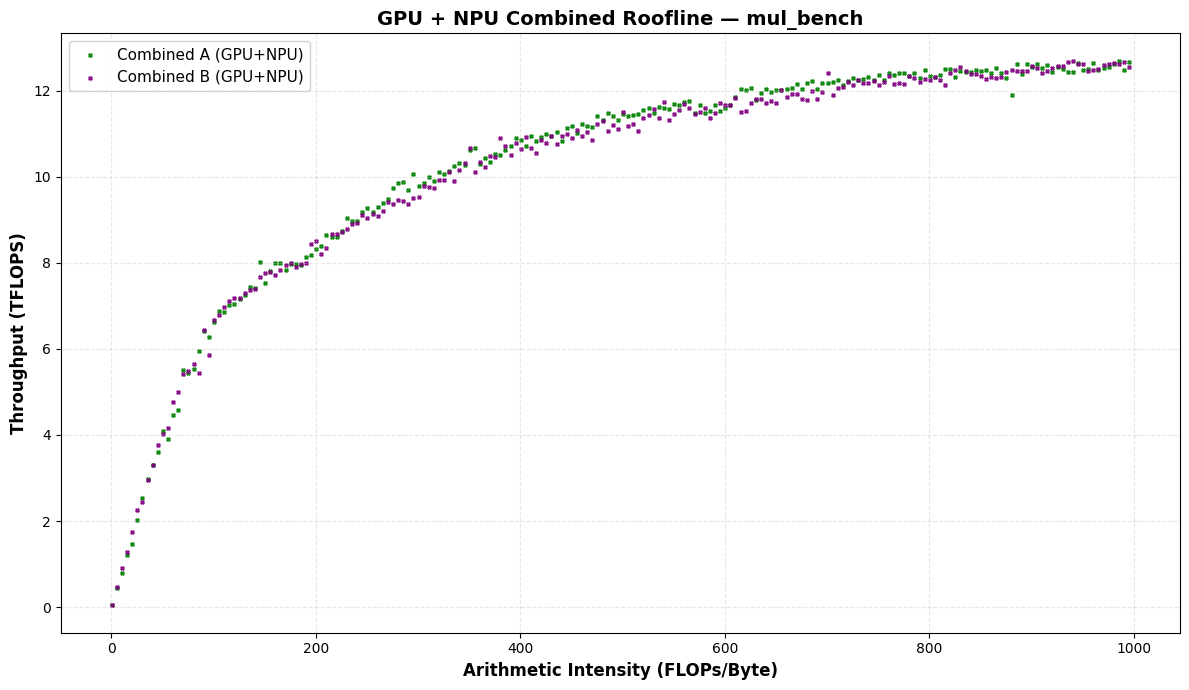

In [ ]:
# ── Plot ───────────────────────────────────────────────────────────────────────
#gpu_ai     = np.array([p[0] for p in gpu_points2])
#gpu_tflops = np.array([p[1] for p in gpu_points2])
#npu_ai     = np.array([p[0] for p in npu_points])
#npu_tflops = np.array([p[1] for p in npu_points])
comb_ai_a   = np.array([p[0] for p in combined_points_a if p[1] is not None])
comb_tflops_a = np.array([p[1] for p in combined_points_a if p[1] is not None])
comb_ai_b   = np.array([p[0] for p in combined_points_b if p[1] is not None])
comb_tflops_b = np.array([p[1] for p in combined_points_b if p[1] is not None])

def upper_envelope(ai, tflops):
    order = np.argsort(ai)
    return ai[order], np.maximum.accumulate(tflops[order])

#gpu_env_ai, gpu_env = upper_envelope(gpu_ai,  gpu_tflops)
#npu_env_ai, npu_env = upper_envelope(npu_ai,  npu_tflops)
#comb_env_ai, comb_env = upper_envelope(comb_ai_a, comb_tflops_a)

#gpu_roofline = np.minimum(gpu_perf, gpu_mem * gpu_env_ai) / 1000
#npu_roofline = np.minimum(npu_perf, npu_mem * npu_env_ai) / 1000
#comb_roofline = np.minimum(gpu_roofline + npu_roofline, total_mem * npu_env_ai / 1000)
#comb_roofline = np.minimum(npu_env_ai * 0.84, npu_tflops + gpu_tflops)

fig, ax = plt.subplots(figsize=(12, 7))

#ax.scatter(gpu_ai, gpu_tflops, s=6, alpha=0.6, color="royalblue",  label="GPU (measured)")
#ax.scatter(npu_ai, npu_tflops, s=6, alpha=0.6, color="darkorange", label="NPU (measured)")
ax.scatter(comb_ai_a, comb_tflops_a, s=6, alpha=0.8, color="green", marker="X", label="Combined A (GPU+NPU)")
ax.scatter(comb_ai_b, comb_tflops_b, s=6, alpha=0.8, color="purple", marker="X", label="Combined B (GPU+NPU)")

#ax.plot(npu_env_ai, comb_roofline, color="green", linewidth=2.5, linestyle="--", label="Combined roofline (Emperical model)")

ax.set_xlabel("Arithmetic Intensity (FLOPs/Byte)", fontsize=12, fontweight="bold")
ax.set_ylabel("Throughput (TFLOPS)",               fontsize=12, fontweight="bold")
ax.set_title("GPU + NPU Combined Roofline — mul_bench", fontsize=14, fontweight="bold")
ax.grid(True, which="both", alpha=0.3, linestyle="--")
ax.legend(fontsize=11, framealpha=0.9)
"""
if len(gpu_points):
    ax.annotate(
        f"GPU peak: {gpu_tflops.max():.3f} TFLOPS",
        xy=(gpu_ai[gpu_tflops.argmax()], gpu_tflops.max()),
        xytext=(10, -20), textcoords="offset points",
        fontsize=9, color="royalblue",
        arrowprops=dict(arrowstyle="->", color="royalblue"),
    )
if len(npu_points):
    ax.annotate(
        f"NPU peak: {npu_tflops.max():.3f} TFLOPS",
        xy=(npu_ai[npu_tflops.argmax()], npu_tflops.max()),
        xytext=(10, 15), textcoords="offset points",
        fontsize=9, color="darkorange",
        arrowprops=dict(arrowstyle="->", color="darkorange"),
    )
"""
plt.tight_layout()
plt.show()

In [209]:
# Real benchmark: vary GPU/NPU batch distribution around gpu_npu_sweep baseline.
import numpy as np
import matplotlib.pyplot as plt


# Reuse current notebook values when present.
gpu_perf =  7500
npu_perf =  6400
gpu_mem = 74.5
npu_mem = 30
total_mem = 74.5
total_batches = 100
repeats = 10
rs = list(range(1, 3000, 1))

# Keep this run practical by default; override by defining rs_bias before running this cell.


def bench_with_batch_bias(rs_values, npu_batch_bias=0, use_measured_points=True):
    """
    npu_batch_bias > 0  => give a few more batches to NPU
    npu_batch_bias < 0  => give a few fewer batches to NPU
    """
    points = []
    for idx, r in enumerate(rs_values):
        ai = r / 2.0
        try:
            # Same baseline split logic as gpu_npu_sweep.
            if use_measured_points:
                gpu_point = gpu_points2[r - 1] if gpu_points2 else None
                if gpu_point[0] != ai:
                    raise ValueError(f"GPU point AI mismatch at R={r}: expected {ai}, got {gpu_point[0]}")
                npu_point = npu_points[r - 1] if npu_points else None
                gpu_need = gpu_point[1] * 1000 / gpu_point[0]
                npu_need = npu_point[1] * 1000 / npu_point[0]
                mem_cap = min(total_mem, gpu_need + npu_need)
            else:
                gpu_need = min(gpu_perf / ai, gpu_mem)
                npu_need = min(npu_perf / ai, npu_mem)
                mem_cap = min(total_mem, gpu_need + npu_need)

            base_gpu_batches = int(total_batches * (gpu_need / max(mem_cap, 1e-12)))
            base_npu_batches = total_batches - base_gpu_batches
            if base_npu_batches == 0:
                base_npu_batches = 1
                base_gpu_batches = total_batches - 1

            # Apply controlled bias to batch distribution.
            npu_batches = int(np.clip(base_npu_batches + npu_batch_bias, 1, total_batches - 1))
            gpu_batches = total_batches - npu_batches
            data = run_bench(r, iters_gpu=gpu_batches, iters_npu=npu_batches, repeats=repeats)
            tflops = data.get("combined_tflops")
            points.append((ai, tflops, gpu_batches, npu_batches))

            msg = (
                f"[{idx+1}/{len(rs_values)}] R={r:5d} AI={ai:7.2f} "
                f"GPU={gpu_batches:3d} NPU={npu_batches:3d}"
            )
            if tflops is not None:
                msg += f" -> {tflops:.4f} TFLOPS, Combined Bandwidth: {tflops*1000/ai:.2f} GB/s"
            else:
                msg += " -> no result"
            print(msg)
        except Exception as exc:
            print(f"[{idx+1}/{len(rs_values)}] R={r:5d} FAILED: {exc}")
            points.append((ai, None, None, None))
    return points

# Use +/- 5 batches as the "little more / little less" default shift.

#measured_more_npu_pts = bench_with_batch_bias(rs, npu_batch_bias=+int(np.floor(total_batches/10)), use_measured_points=True)
#measured_less_npu_pts = bench_with_batch_bias(rs, npu_batch_bias=-int(np.floor(total_batches/10)), use_measured_points=True)
#measured_baseline_pts = bench_with_batch_bias(rs, npu_batch_bias=0, use_measured_points=True)

more_npu_pts = bench_with_batch_bias(rs, npu_batch_bias=+int(np.floor(total_batches/10)), use_measured_points=False)
less_npu_pts = bench_with_batch_bias(rs, npu_batch_bias=-int(np.floor(total_batches/10)), use_measured_points=False)
baseline_pts = bench_with_batch_bias(rs, npu_batch_bias=0, use_measured_points=False)




[1/2999] R=    1 AI=   0.50 GPU= 89 NPU= 11 -> 0.0336 TFLOPS, Combined Bandwidth: 67.28 GB/s
[2/2999] R=    2 AI=   1.00 GPU= 89 NPU= 11 -> 0.0650 TFLOPS, Combined Bandwidth: 64.96 GB/s
[3/2999] R=    3 AI=   1.50 GPU= 89 NPU= 11 -> 0.0997 TFLOPS, Combined Bandwidth: 66.49 GB/s
[4/2999] R=    4 AI=   2.00 GPU= 89 NPU= 11 -> 0.1298 TFLOPS, Combined Bandwidth: 64.88 GB/s
[5/2999] R=    5 AI=   2.50 GPU= 89 NPU= 11 -> 0.1594 TFLOPS, Combined Bandwidth: 63.75 GB/s
[6/2999] R=    6 AI=   3.00 GPU= 89 NPU= 11 -> 0.2064 TFLOPS, Combined Bandwidth: 68.80 GB/s
[7/2999] R=    7 AI=   3.50 GPU= 89 NPU= 11 -> 0.2234 TFLOPS, Combined Bandwidth: 63.82 GB/s
[8/2999] R=    8 AI=   4.00 GPU= 89 NPU= 11 -> 0.2806 TFLOPS, Combined Bandwidth: 70.15 GB/s
[9/2999] R=    9 AI=   4.50 GPU= 89 NPU= 11 -> 0.2923 TFLOPS, Combined Bandwidth: 64.95 GB/s
[10/2999] R=   10 AI=   5.00 GPU= 89 NPU= 11 -> 0.3383 TFLOPS, Combined Bandwidth: 67.66 GB/s
[11/2999] R=   11 AI=   5.50 GPU= 89 NPU= 11 -> 0.3558 TFLOPS, Combin


Summary:
Baseline mean TFLOPS: 10.5826
Measured Baseline mean TFLOPS: 11.0368
More-NPU mean TFLOPS: 8.9468
Less-NPU mean TFLOPS: 10.1073


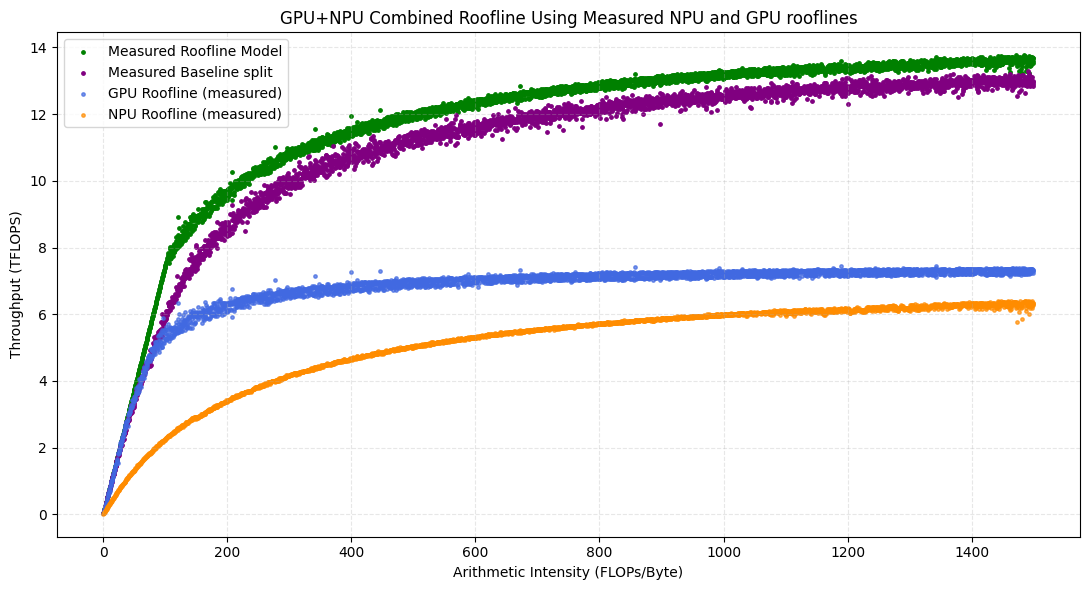

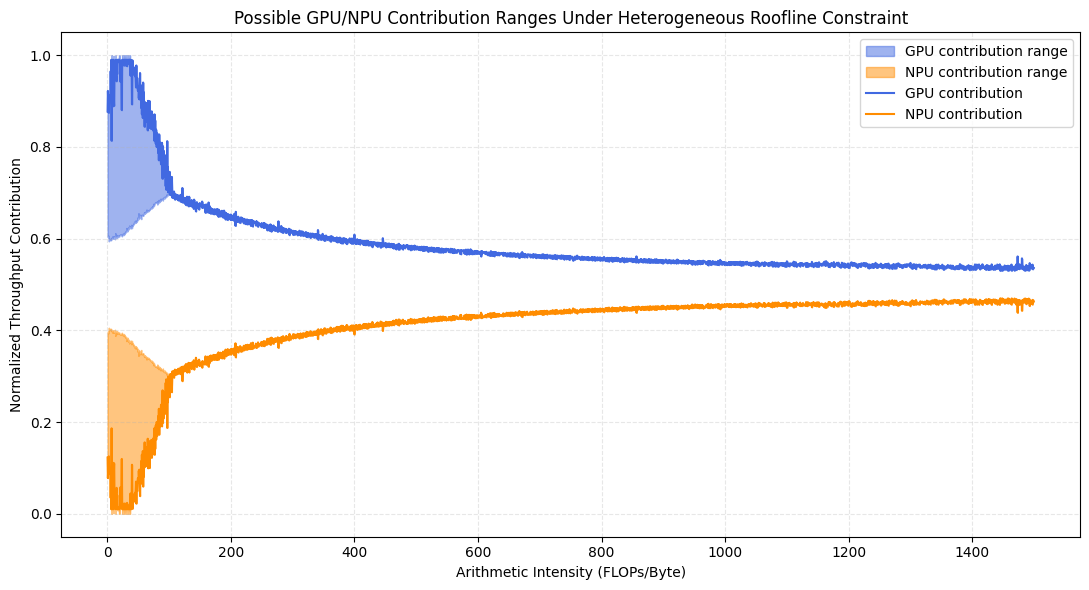

In [222]:
def to_arrays(points):
    valid = [p for p in points if p[1] is not None]
    if not valid:
        return np.array([]), np.array([])
    return np.array([p[0] for p in valid]), np.array([p[1] for p in valid])

ai_base, t_base = to_arrays(baseline_pts)
ai_measured_base, t_measured_base = to_arrays(measured_baseline_pts)
ai_more, t_more = to_arrays(more_npu_pts)
ai_less, t_less = to_arrays(less_npu_pts)
ai_measured_more, t_measured_more = to_arrays(measured_more_npu_pts)
ai_measured_less, t_measured_less = to_arrays(measured_less_npu_pts)

# Build aligned GPU/NPU throughput arrays at the same AI points as measured baseline.
gpu_ai_pts = np.array([p[0] for p in gpu_points2], dtype=float)
gpu_tf_pts = np.array([p[1] for p in gpu_points2], dtype=float)
npu_ai_pts = np.array([p[0] for p in npu_points], dtype=float)
npu_tf_pts = np.array([p[1] for p in npu_points], dtype=float)

if len(ai_measured_base) == 0 or len(gpu_ai_pts) == 0 or len(npu_ai_pts) == 0:
    measured_roofline = np.array([])
else:
    gpu_ref = np.interp(ai_measured_base, gpu_ai_pts, gpu_tf_pts)
    npu_ref = np.interp(ai_measured_base, npu_ai_pts, npu_tf_pts)
    measured_roofline = np.minimum(ai_measured_base * total_mem / 1000.0, gpu_ref + npu_ref)

print("\nSummary:")
if len(t_base):
    print(f"Baseline mean TFLOPS: {t_base.mean():.4f}")
if len(t_measured_base):
    print(f"Measured Baseline mean TFLOPS: {t_measured_base.mean():.4f}")
if len(t_more):
    print(f"More-NPU mean TFLOPS: {t_more.mean():.4f}")
if len(t_less):
    print(f"Less-NPU mean TFLOPS: {t_less.mean():.4f}")
    # Normalize GPU/NPU contributions by hetero roofline (avoid undefined P1/P2/P_het).


if len(ai_measured_base) == 0 or len(measured_roofline) == 0:
    P1_max = np.array([])
    P2_max = np.array([])
    P1_min = np.array([])
    P2_min = np.array([])
else:
    P1 = np.asarray(gpu_ref, dtype=float)   # GPU throughput at baseline AI points
    P2 = np.asarray(npu_ref, dtype=float)   # NPU throughput at baseline AI points
    P_het = measured_roofline  # Heterogeneous roofline at baseline AI points

    P1_max = np.minimum(P1 / P_het, 1.0)
    P2_max = np.minimum(P2 / P_het, 1.0)

    # Lower-bound complements
    P1_min = np.maximum(0.0, 1.0 - P2_max)
    P2_min = np.maximum(0.0, 1.0 - P1_max)

    #actual contributions
    P1_contrib = np.minimum(P1 / P_het, 0.99)
    P2_contrib = np.maximum(0.01, 1.0 - P1_max)



plt.figure(figsize=(11, 6))

#plt.scatter(ai_measured_base, t_measured_base, color="green", s = 6, alpha=1, label="Baseline split (model)")
plt.scatter(ai_measured_base, measured_roofline, color="green", s = 6, alpha=1, label="Measured Roofline Model")

#plt.plot(ai_base, t_base, marker="o", markersize=2, linewidth=0.7, label="Baseline split")
#plt.plot(ai_more, t_more, marker="s", markersize=2, linewidth=0.7, linestyle="--", label="More NPU (+10% batches)", alpha=0.3)
#plt.plot(ai_less, t_less, marker="^", markersize=2, linewidth=0.7, linestyle=":", label="Less NPU (-10% batches)", alpha=0.3)

#plt.plot(ai_measured_base, t_measured_base, marker="o", markersize=2, linewidth=0.7, linestyle="--", label="Measured Baseline split")
#plt.plot(ai_measured_more, t_measured_more, marker="s", markersize=2, linewidth=0.7, linestyle="--", label="Measured More NPU (+10% batches)", alpha=0.3)
#plt.plot(ai_measured_less, t_measured_less, marker="^", markersize=2, linewidth=0.7, linestyle=":", label="Measured Less NPU (-10% batches)", alpha=0.3)


plt.scatter(ai_measured_base, t_measured_base, color="purple", s = 6, alpha=1, label="Measured Baseline split")
plt.scatter(gpu_ai_pts, gpu_tf_pts, color="royalblue", s = 6, alpha=0.7, label="GPU Roofline (measured)")
plt.scatter(npu_ai_pts, npu_tf_pts, color="darkorange", s = 6, alpha=0.7, label="NPU Roofline (measured)")
plt.xlabel("Arithmetic Intensity (FLOPs/Byte)")
#plt.ylabel("Measured Combined Throughput (TFLOPS)")
#plt.title("Measured Throughput vs Batch Distribution Bias")

plt.ylabel("Throughput (TFLOPS)")
plt.title("GPU+NPU Combined Roofline Using Measured NPU and GPU rooflines")

plt.grid(True, alpha=0.3, linestyle="--")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(11, 6)) 
#want to plot P1_max, P2_max, P1_min, P2_min as stacked area plot to show the range of possible GPU/NPU contributions under the hetero roofline constraint.
plt.fill_between(ai_measured_base, P1_min, P1_max, color="royalblue", alpha=0.5, label="GPU contribution range")
plt.fill_between(ai_measured_base, P2_min, P2_max, color="darkorange", alpha=0.5, label="NPU contribution range")
plt.plot(ai_measured_base, P1_contrib, color="royalblue", linewidth=1.5, label="GPU contribution")
plt.plot(ai_measured_base, P2_contrib, color="darkorange", linewidth=1.5, label="NPU contribution")
plt.xlabel("Arithmetic Intensity (FLOPs/Byte)")
plt.ylabel("Normalized Throughput Contribution")
plt.title("Possible GPU/NPU Contribution Ranges Under Heterogeneous Roofline Constraint")
plt.grid(True, alpha=0.3, linestyle="--")
plt.legend()
plt.tight_layout()
plt.show()

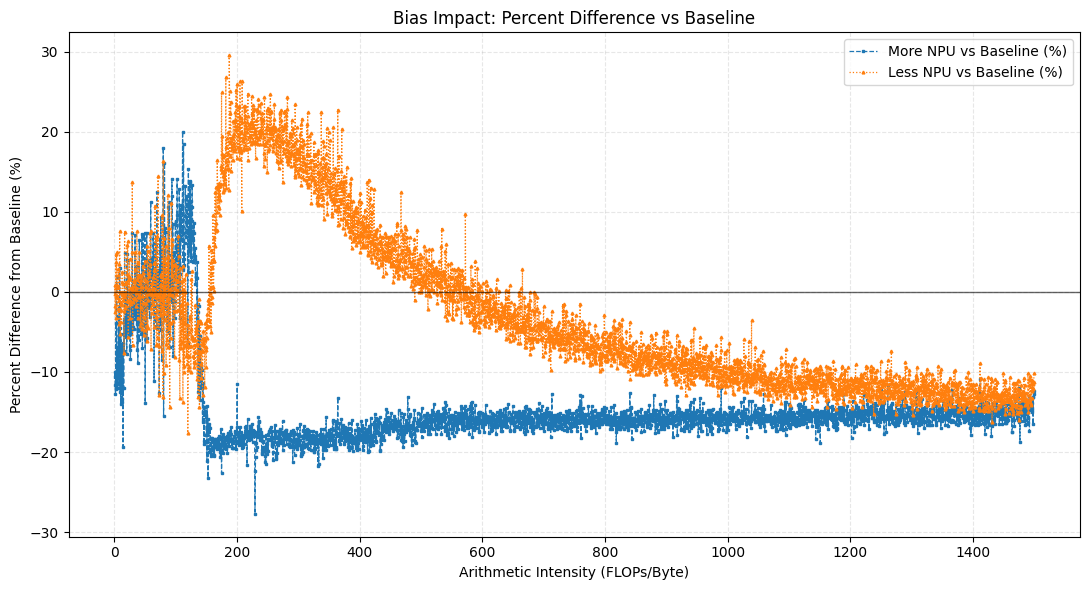

More NPU: mean=-14.697%  min=-27.714%  max=19.991%
Less NPU: mean=-2.912%  min=-17.588%  max=29.536%


In [213]:
# ── Percent difference vs baseline ─────────────────────────────────────────────
# %diff = (biased - baseline) / baseline * 100

if len(ai_base) == 0 or len(t_base) == 0:
    raise ValueError("Baseline arrays are empty. Run the baseline benchmark cell first.")

ai_ref = ai_base
base_ref = t_base

more_ref = np.interp(ai_ref, ai_more, t_more) if len(ai_more) else np.full_like(ai_ref, np.nan)
less_ref = np.interp(ai_ref, ai_less, t_less) if len(ai_less) else np.full_like(ai_ref, np.nan)

with np.errstate(divide="ignore", invalid="ignore"):
    pct_more = (more_ref - base_ref) / base_ref * 100.0
    pct_less = (less_ref - base_ref) / base_ref * 100.0

# Remove non-finite points for cleaner plotting.
mask_more = np.isfinite(pct_more)
mask_less = np.isfinite(pct_less)

plt.figure(figsize=(11, 6))
if np.any(mask_more):
    plt.plot(ai_ref[mask_more], pct_more[mask_more], marker="s", markersize=2, linewidth=0.9, linestyle="--", label="More NPU vs Baseline (%)")
if np.any(mask_less):
    plt.plot(ai_ref[mask_less], pct_less[mask_less], marker="^", markersize=2, linewidth=0.9, linestyle=":", label="Less NPU vs Baseline (%)")

plt.axhline(0.0, color="black", linewidth=1.0, alpha=0.6)
plt.xlabel("Arithmetic Intensity (FLOPs/Byte)")
plt.ylabel("Percent Difference from Baseline (%)")
plt.title("Bias Impact: Percent Difference vs Baseline")
plt.grid(True, alpha=0.3, linestyle="--")
plt.legend()
plt.tight_layout()
plt.show()

if np.any(mask_more):
    print(f"More NPU: mean={np.nanmean(pct_more):.3f}%  min={np.nanmin(pct_more):.3f}%  max={np.nanmax(pct_more):.3f}%")
if np.any(mask_less):
    print(f"Less NPU: mean={np.nanmean(pct_less):.3f}%  min={np.nanmin(pct_less):.3f}%  max={np.nanmax(pct_less):.3f}%")

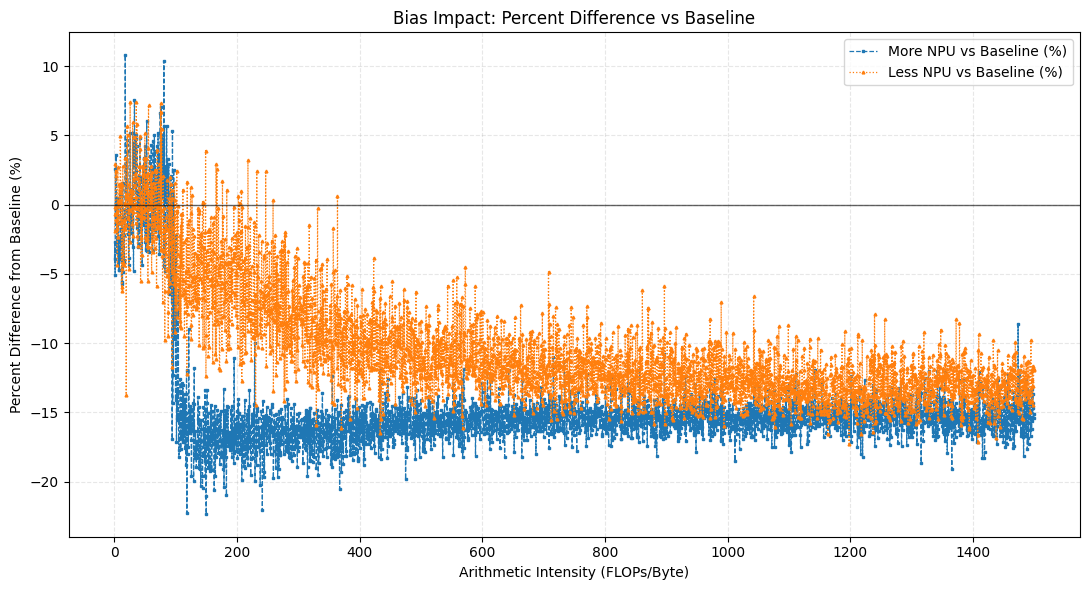

More NPU: mean=-14.605%  min=-22.317%  max=10.787%
Less NPU: mean=-10.444%  min=-17.247%  max=7.439%


In [ ]:
# ── Percent difference vs baseline ─────────────────────────────────────────────
# %diff = (biased - baseline) / baseline * 100

if len(ai_base) == 0 or len(t_base) == 0:
    raise ValueError("Baseline arrays are empty. Run the baseline benchmark cell first.")

ai_ref = ai_measured_base
base_ref = t_measured_base
gpu_perf =  7000
npu_perf =  4500
gpu_mem = 74.5
npu_mem = 20
total_mem = 74.5
total_batches = 100
more_ref = np.interp(ai_ref, ai_measured_more, t_measured_more) if len(ai_measured_more) else np.full_like(ai_ref, np.nan)
less_ref = np.interp(ai_ref, ai_measured_less, t_measured_less) if len(ai_measured_less) else np.full_like(ai_ref, np.nan)

with np.errstate(divide="ignore", invalid="ignore"):
    pct_more = (more_ref - base_ref) / base_ref * 100.0
    pct_less = (less_ref - base_ref) / base_ref * 100.0

# Remove non-finite points for cleaner plotting.
mask_more = np.isfinite(pct_more)
mask_less = np.isfinite(pct_less)

plt.figure(figsize=(11, 6))
if np.any(mask_more):
    plt.plot(ai_ref[mask_more], pct_more[mask_more], marker="s", markersize=2, linewidth=0.9, linestyle="--", label="More NPU vs Baseline (%)")
if np.any(mask_less):
    plt.plot(ai_ref[mask_less], pct_less[mask_less], marker="^", markersize=2, linewidth=0.9, linestyle=":", label="Less NPU vs Baseline (%)")

plt.axhline(0.0, color="black", linewidth=1.0, alpha=0.6)
plt.xlabel("Arithmetic Intensity (FLOPs/Byte)")
plt.ylabel("Percent Difference from Baseline (%)")
plt.title("Bias Impact: Percent Difference vs Baseline")
plt.grid(True, alpha=0.3, linestyle="--")
plt.legend()
plt.tight_layout()
plt.show()

if np.any(mask_more):
    print(f"More NPU: mean={np.nanmean(pct_more):.3f}%  min={np.nanmin(pct_more):.3f}%  max={np.nanmax(pct_more):.3f}%")
if np.any(mask_less):
    print(f"Less NPU: mean={np.nanmean(pct_less):.3f}%  min={np.nanmin(pct_less):.3f}%  max={np.nanmax(pct_less):.3f}%")